### Loading Data

In [110]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [111]:
df = pd.read_csv('./data/customer_churn_dataset-testing-master.csv')

<small>Infor about the dataset </small>

In [112]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [114]:
df.shape

(64374, 12)

<small>Checking for columns </small>

In [115]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

<small>Dropping CustomerID, as identifier this shouldn't affect the data </small>

In [116]:
df = df.drop(columns=['CustomerID'])  # dropping unnecessary index column   

In [117]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [118]:
numerical_cols = df.drop(columns=categorical_cols).columns
numerical_cols = numerical_cols.drop('Churn')  # target variable

In [119]:
print('unique values in first categorical column:')
print(df[categorical_cols[0]].unique())  # Binary so Label Encoding can be used
print('unique values in second categorical column:')
print(df[categorical_cols[1]].unique()) # Categorical has tiers so Ordinal Encoding can be used
print('unique values in third categorical column:')
print(df[categorical_cols[2]].unique()) # Categorical has no order so One-Hot Encoding can be used

unique values in first categorical column:
['Female' 'Male']
unique values in second categorical column:
['Basic' 'Standard' 'Premium']
unique values in third categorical column:
['Monthly' 'Annual' 'Quarterly']


### Data Cleaning

<small>Checking for nulls</small>

In [120]:
df.isnull().sum()  # no nulls

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

<small>checking for duplicates </small>

In [121]:
df.duplicated().sum()  # no duplicates

np.int64(0)

### Data Analysis

Basedd on the countplots, it seems that 'Contract' type has a significant impact on churn rates. Customers with month-to-month contracts tend to churn more compared to those with one-year or two-year contracts.


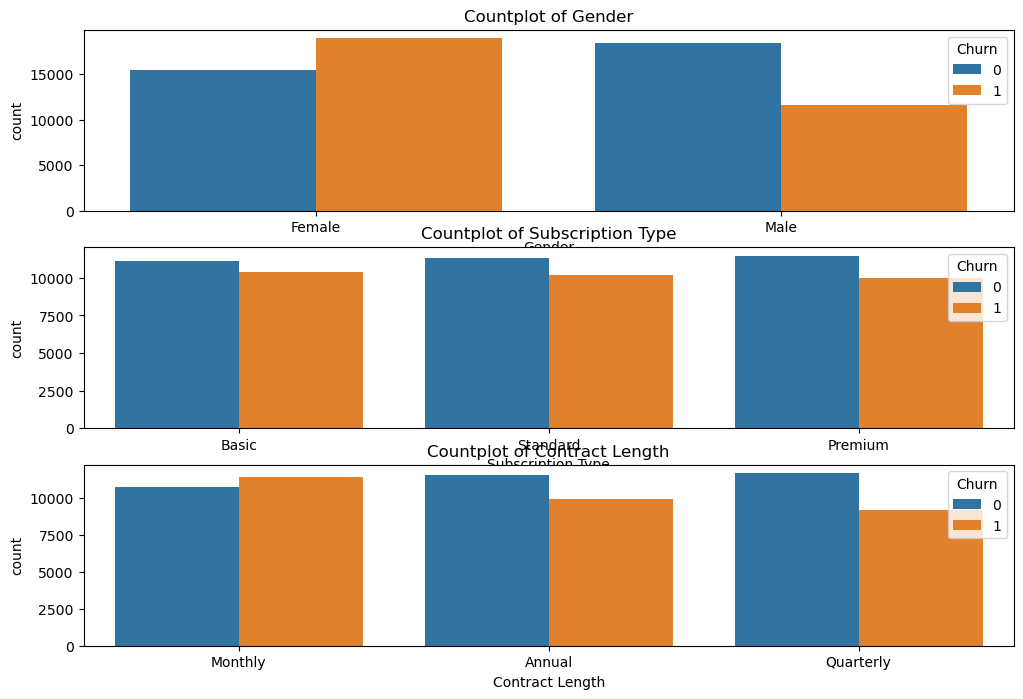

In [122]:
fig,axes = plt.subplots(3,1, figsize=(12,8))
for col in categorical_cols:
   sns.countplot(data=df, x=col, hue='Churn', ax=axes[categorical_cols.get_loc(col)])
   axes[categorical_cols.get_loc(col)].set_title(f'Countplot of {col}')
print("Basedd on the countplots, it seems that 'Contract' type has a significant impact on churn rates. Customers with month-to-month contracts tend to churn more compared to those with one-year or two-year contracts.")

Age is approximately symmetric with skewness of -0.040893617755290594
Tenure is approximately symmetric with skewness of -0.12605627128660457
Usage Frequency is approximately symmetric with skewness of 0.03754298828827117
Support Calls is approximately symmetric with skewness of -0.19285414431875514
Payment Delay is approximately symmetric with skewness of -0.35071402695836457
Total Spend is approximately symmetric with skewness of 0.04774634961486376
Last Interaction is approximately symmetric with skewness of 0.005111808910520158
from the above, it seems that all continuous numerical column are approximately symmetric.


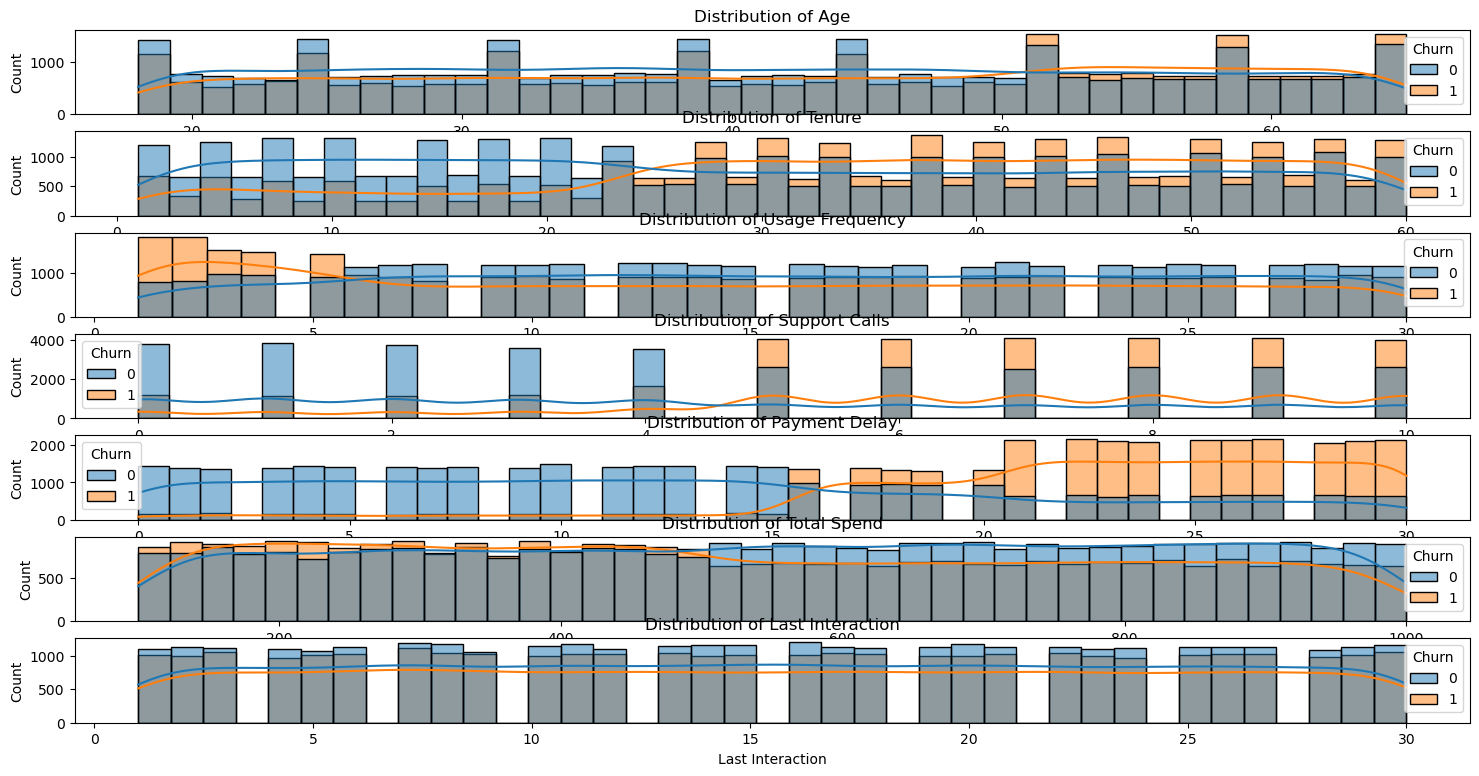

In [123]:
fig, ax = plt.subplots(len(numerical_cols),1,figsize=(18,9))
for i, cols in enumerate(numerical_cols):
    sns.histplot(data=df, x=cols, hue='Churn', kde=True, ax=ax[i])
    ax[i].set_title(f'Distribution of {cols}')
    if df[cols].skew() > 1 or df[cols].skew() < -1:
        print(f'{cols} is highly skewed with skewness of {df[cols].skew()}')
    elif df[cols].skew() > 0.5 or df[cols].skew() < -0.5:
        print(f'{cols} is moderately skewed with skewness of {df[cols].skew()}')
    else:
        print(f'{cols} is approximately symmetric with skewness of {df[cols].skew()}')

print('from the above, it seems that all continuous numerical column are approximately symmetric.')
    

### Encoding

<small>Correlation with Target and Categorical Features </small>

In [124]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [ ]:
le = LabelEncoder()
oe = OrdinalEncoder(categories=[df[categorical_cols[1]].unique().tolist()])
ohe = OneHotEncoder(sparse_output=False)

# Applying Label Encoding to the first categorical column (binary)
df[categorical_cols[0]] = le.fit_transform(df[categorical_cols[0]])

# Applying Ordinal Encoding to the second categorical column (tiers)
df[categorical_cols[1]] = oe.fit_transform(df[[categorical_cols[1]]])

#Applying One-Hot Encoding to the third categorical column (no order)
ohe_df = pd.DataFrame(ohe.fit_transform(df[[categorical_cols[2]]]), columns=ohe.get_feature_names_out([categorical_cols[2]]))
encoded_df = pd.concat([df.drop(columns=[categorical_cols[2]]), ohe_df], axis=1)

encoded_df.head()


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,22,0,25,14,4,27,0.0,598,9,1,0.0,1.0,0.0
1,41,0,28,28,7,13,1.0,584,20,0,0.0,1.0,0.0
2,47,1,27,10,2,29,2.0,757,21,0,1.0,0.0,0.0
3,35,1,9,12,5,17,2.0,232,18,0,0.0,0.0,1.0
4,53,0,58,24,9,2,1.0,533,18,0,1.0,0.0,0.0


<small>Correlation using a heat map- to identify how values correlate </small>

The highest correlations with the target variable Churn are Payment Delay(0.56), Support Calls(0.3) and Tenure(0.2, Everything else shows low correlation. Unless you push further and consider Gender)


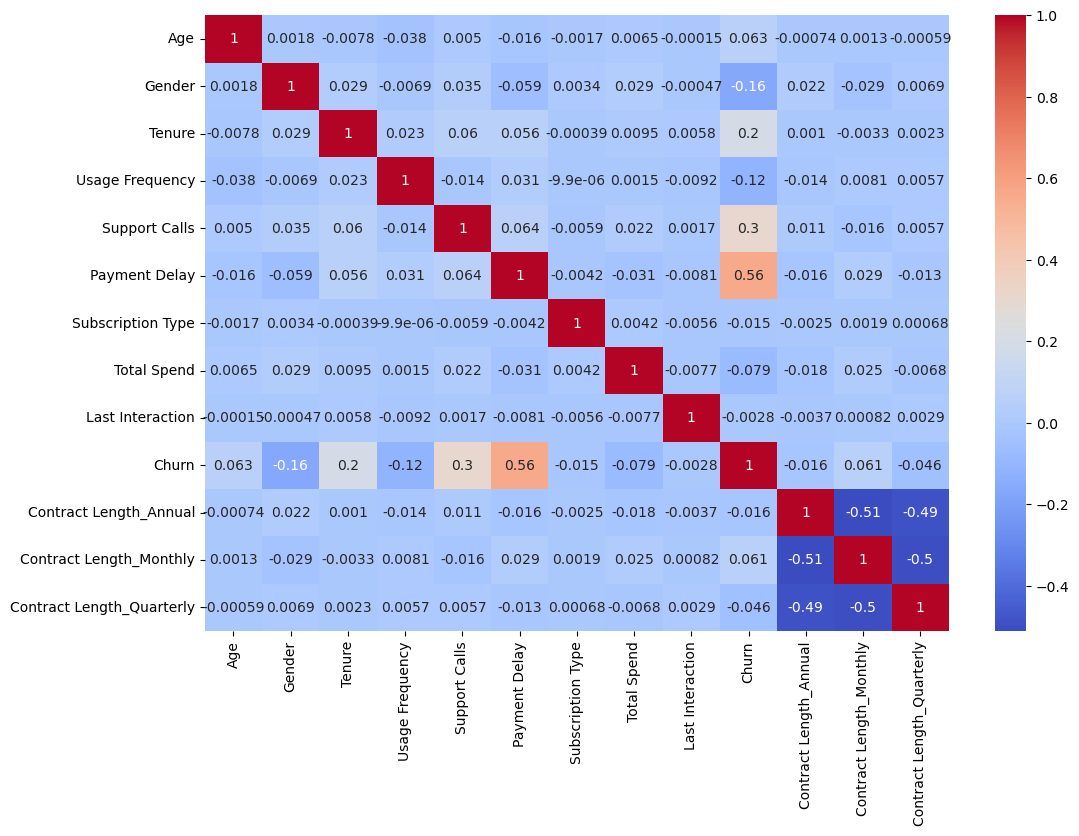

In [126]:
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm')
print('The highest correlations with the target variable Churn are Payment Delay(0.56), Support Calls(0.3) and Tenure(0.2, Everything else shows low correlation. Unless you push further and consider Gender)')


### Dealing with Outliers, Extreme Cases and Erroneous Data Inputs

<small>Remove outliers using IQR method</small>

In [ ]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


<small>Show bounds function IQR method</small>

In [ ]:
def show_bounds_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

<small>check for z score outliers </small>

In [129]:

def identify_outliers_zscore(df, column, threshold=3):
 
    mean = df[column].mean()
    std = df[column].std()

    # Compute z-scores
    z_scores = (df[column] - mean) / std

    # Return rows where absolute z-score exceeds threshold
    return df[np.abs(z_scores) > threshold]


<small>remove using the z score approach for normal distributed </small>

In [130]:

def remove_outliers_zscore(df, column, threshold=3):
   
    mean = df[column].mean()
    std = df[column].std()

    z_scores = (df[column] - mean) / std
    return df[np.abs(z_scores) <= threshold]


<small>check extreme values that deviate from the median given a threshold </small>

In [131]:
def check_extremes_from_edges(series, threshold=0.30):
 
    median = series.median()
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val

    lower_bound = median - threshold * range_val
    upper_bound = median + threshold * range_val

    return {
        "min_value": min_val,
        "min_class": "Lower Extreme" if min_val < lower_bound else "Normal",
        "max_value": max_val,
        "max_class": "Upper Extreme" if max_val > upper_bound else "Normal",
        "median": median,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }


<small>remove extremes if needed using threshold based ranges </small>

In [132]:

def remove_outliers_threshold(df, column, threshold=0.25):
  
    median = df[column].median()
    min_val = df[column].min()
    max_val = df[column].max()
    range_val = max_val - min_val

    lower_bound = median - threshold * range_val
    upper_bound = median + threshold * range_val

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


<small> With Payment Delay and Churn (0.56 Correlation)</small>

Shows outliers in Payment Delay for Churned and Non Churned customers.
But confirms that Churn customers have higher Payment Delay on average.


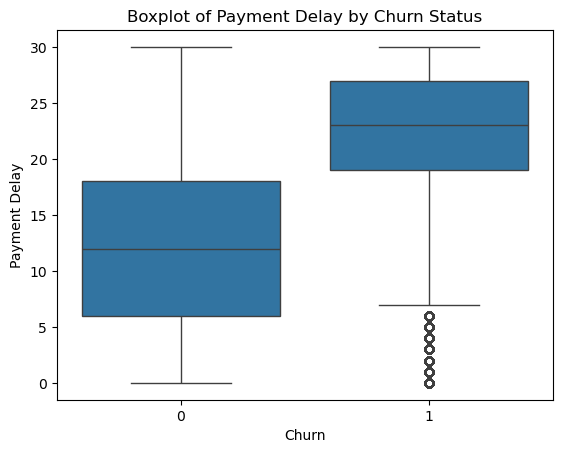

In [133]:
sns.boxplot(data=encoded_df, x='Churn', y='Payment Delay')
plt.title('Boxplot of Payment Delay by Churn Status')
print('Shows outliers in Payment Delay for Churned and Non Churned customers.')
print('But confirms that Churn customers have higher Payment Delay on average.')

In [134]:
# show lower bounds of Payment Delay
show_bounds(encoded_df, 'Payment Delay')
print('Seeing that the lower bound is negative, we will remove any outliers on the lower end for Payment Delay as it does not make sense to have negative delay.')

lower bound -12.5
upper bound 47.5
Seeing that the lower bound is negative, we will remove any outliers on the lower end for Payment Delay as it does not make sense to have negative delay.


In [135]:
encoded_df = remove_outliers(encoded_df, 'Payment Delay')
encoded_df = encoded_df[encoded_df['Payment Delay'] >= 0]

<small> Checking for extreme cases </small>

In [136]:
check_extremes_from_edges(encoded_df['Payment Delay'])

{'min_value': 0,
 'min_class': 'Lower Extreme',
 'max_value': 30,
 'max_class': 'Upper Extreme',
 'median': 19.0,
 'lower_bound': 10.0,
 'upper_bound': 28.0}

In [137]:
identify_outliers_zscore(encoded_df, 'Payment Delay') # none found

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly


<small>With Support Calls and Churn (0.3) Correlation</small>

Shows no significant outliers in Support Calls for Churned and Non Churned customers.
But confirms that Churn customers have higher number of Support Calls on average.


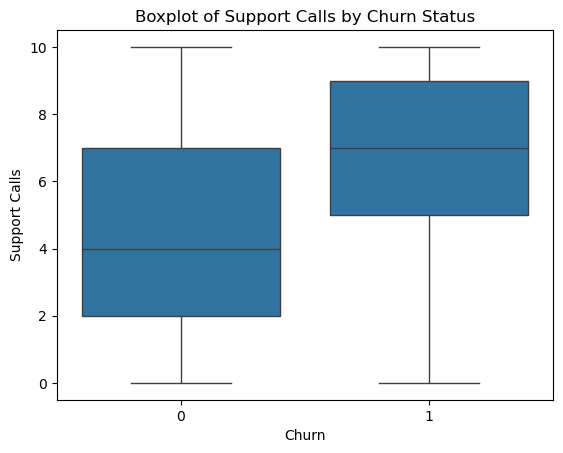

In [138]:
sns.boxplot(data=encoded_df, x='Churn', y='Support Calls')
plt.title('Boxplot of Support Calls by Churn Status')
print('Shows no significant outliers in Support Calls for Churned and Non Churned customers.')
print('But confirms that Churn customers have higher number of Support Calls on average.')

In [139]:
# show bounds of Support Calls
show_bounds(encoded_df, 'Support Calls')
print('Seeing that the lower bound is negative, we will remove any outliers on the lower end for Support Calls as it does not make sense to have negative support calls.')

lower bound -4.5
upper bound 15.5
Seeing that the lower bound is negative, we will remove any outliers on the lower end for Support Calls as it does not make sense to have negative support calls.


In [140]:
encoded_df = remove_outliers(encoded_df, 'Support Calls')
encoded_df = encoded_df[encoded_df['Support Calls'] >= 0]

<small>with Tenure and Churn(0.2 Correlation)</small>

Shows no significant outliers in Tenure for Churned and Non Churned customers.
But confirms that Churn customers have lower Tenure on average.


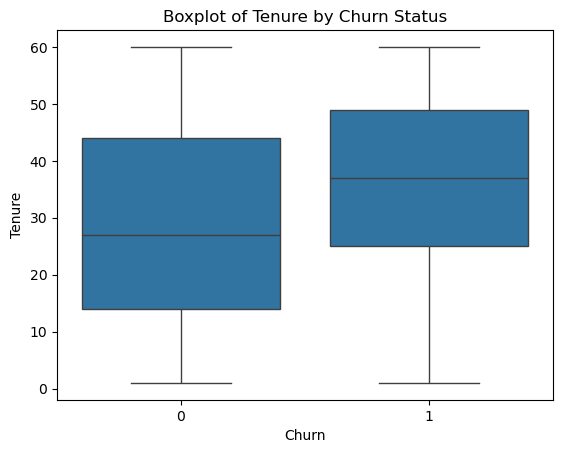

In [141]:
sns.boxplot(data=encoded_df, x='Churn', y='Tenure')
plt.title('Boxplot of Tenure by Churn Status')
print('Shows no significant outliers in Tenure for Churned and Non Churned customers.')
print('But confirms that Churn customers have lower Tenure on average.')

In [142]:
#show the bounds of Tenure
show_bounds(encoded_df, 'Tenure')
print('Seeing that the lower bound is negative, we will remove any outliers on the lower end for Tenure as it does not make sense to have negative tenure.')

lower bound -25.5
upper bound 90.5
Seeing that the lower bound is negative, we will remove any outliers on the lower end for Tenure as it does not make sense to have negative tenure.


In [143]:
encoded_df = remove_outliers(encoded_df, 'Tenure')
encoded_df = encoded_df[encoded_df['Tenure'] >= 0]  

<small>Cleaning out individual rows for unlikely values like negatives etc </small>

In [144]:
numerical_cols

for col in numerical_cols:
    print('Extremes for column:', col)
    print(check_extremes_from_edges(encoded_df[col]))
    
# it looks good now

Extremes for column: Age
{'min_value': 18, 'min_class': 'Lower Extreme', 'max_value': 65, 'max_class': 'Upper Extreme', 'median': 42.0, 'lower_bound': 27.9, 'upper_bound': 56.1}
Extremes for column: Tenure
{'min_value': 1, 'min_class': 'Lower Extreme', 'max_value': 60, 'max_class': 'Upper Extreme', 'median': 33.0, 'lower_bound': 15.3, 'upper_bound': 50.7}
Extremes for column: Usage Frequency
{'min_value': 1, 'min_class': 'Lower Extreme', 'max_value': 30, 'max_class': 'Upper Extreme', 'median': 15.0, 'lower_bound': 6.300000000000001, 'upper_bound': 23.7}
Extremes for column: Support Calls
{'min_value': 0, 'min_class': 'Lower Extreme', 'max_value': 10, 'max_class': 'Upper Extreme', 'median': 6.0, 'lower_bound': 3.0, 'upper_bound': 9.0}
Extremes for column: Payment Delay
{'min_value': 0, 'min_class': 'Lower Extreme', 'max_value': 30, 'max_class': 'Upper Extreme', 'median': 19.0, 'lower_bound': 10.0, 'upper_bound': 28.0}
Extremes for column: Total Spend
{'min_value': 100, 'min_class': 'Low

### Feature Engineering

In [145]:
# Based on the data higher support calls mean that there is higher chance of churn.
encoded_df['High Support Call'] = encoded_df.apply(lambda row: 1 if row['Support Calls'] > encoded_df['Support Calls'].median() else 0, axis=1)

# Based on the data higher payment delay mean that there is higher chance of churn.
encoded_df['High Payment Delay'] = encoded_df.apply(lambda row: 1 if row['Payment Delay'] > encoded_df['Payment Delay'].median() else 0, axis=1)

# Based on the data lower tenure mean that there is higher chance of churn.
encoded_df['Low Tenure'] = encoded_df.apply(lambda row: 1 if row['Tenure'] < encoded_df['Tenure'].median() else 0, axis=1)

# Risk Factor combining all three new features (Ordinal Encoding like, Higher means higher risk)
encoded_df['Risk Factor'] = encoded_df['High Support Call'] + encoded_df['High Payment Delay'] + encoded_df['Low Tenure']

In [146]:
df_final = encoded_df.copy()
df_final.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,High Support Call,High Payment Delay,Low Tenure,Risk Factor
0,22,0,25,14,4,27,0.0,598,9,1,0.0,1.0,0.0,0,1,1,2
1,41,0,28,28,7,13,1.0,584,20,0,0.0,1.0,0.0,1,0,1,2
2,47,1,27,10,2,29,2.0,757,21,0,1.0,0.0,0.0,0,1,1,2
3,35,1,9,12,5,17,2.0,232,18,0,0.0,0.0,1.0,0,0,1,1
4,53,0,58,24,9,2,1.0,533,18,0,1.0,0.0,0.0,1,0,0,1


### Splitting Data

In [147]:
from sklearn.model_selection import train_test_split

In [148]:
# Separate feeatures from target 
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']


In [149]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Training and Distribution of Target Value

<small>visualize the target variable distribution to see if a great difference between minority and marjority, apply only to testing data</small>

<Axes: xlabel='Churn', ylabel='count'>

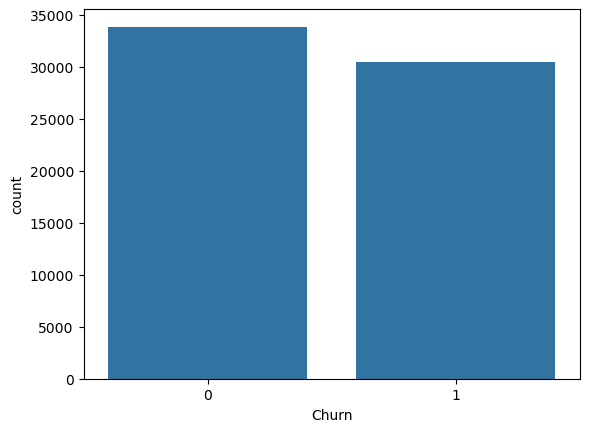

In [150]:
sns.countplot(data=df_final, x='Churn')

You can even out the minority by either removing some majority class samples or by oversampling the minority class samples using techniques like SMOTE or ADASYN. as the disparity is mild it's best to using over-sampling 

In [151]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [152]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [153]:
ros = RandomOverSampler(random_state=42)
# only apply on training data to avoid data leakage
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

<Axes: xlabel='Churn', ylabel='count'>

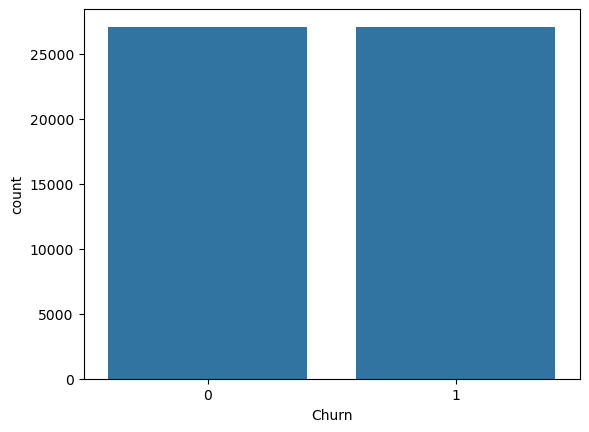

In [154]:
# visualize the new class distribution
sns.countplot(x=y_train_resampled)

### Scaling Data

<small>Not all classifiers need scaled data, like Decision Trees etc, in order to use stuff like KNN and stuff we need to scale data to improve accuracy </small>

In [155]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [156]:
print("Old Scale: ")
print(np.min(X_train_resampled)," <-> " ,np.max(X_train_resampled))

Old Scale: 
0.0  <->  1000.0


In [157]:
# scale only the features (this helps with convergence for some models)
X_train_scaled = scaler.fit_transform(X_train_resampled)

X_test_scaled = scaler.transform(X_test)

In [158]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-1.9750864976796054  <->  1.902645789209738


### Using Classifiers

In [159]:
from sklearn.metrics import classification_report, accuracy_score

### Scaled

Logistic Regression

In [160]:
from sklearn import linear_model
log_reg = linear_model.LogisticRegression()
log_reg.fit(X_train_scaled, y_train_resampled)

LogisticRegression()

In [161]:
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_reg_pred))
print("Accuracy:", log_reg_accuracy)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      6776
           1       0.80      0.84      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

Accuracy: 0.8255533980582525


KNN

In [162]:
from sklearn.neighbors import KNeighborsClassifier
# use the sqrt to get the number of neighbors
k = int(np.sqrt(len(y_test)))
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train_resampled)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))
print("Accuracy:", knn_accuracy)

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      6776
           1       0.89      0.82      0.85      6099

    accuracy                           0.87     12875
   macro avg       0.87      0.86      0.86     12875
weighted avg       0.87      0.87      0.87     12875

Accuracy: 0.8657864077669903


SVM

In [163]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_scaled, y_train_resampled)
svc_pred = svc.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_pred)
print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))
print("Accuracy:", svc_accuracy)

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      6776
           1       0.93      0.97      0.95      6099

    accuracy                           0.95     12875
   macro avg       0.95      0.95      0.95     12875
weighted avg       0.95      0.95      0.95     12875

Accuracy: 0.9500582524271844


### Non Scaled

Decision Tree

In [164]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_resampled, y_train_resampled)
dtc_pred = dtc.predict(X_test)
dtc_accuracy = accuracy_score(y_test, dtc_pred)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dtc_pred))
print("Accuracy:", dtc_accuracy)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

Accuracy: 0.9988349514563106


Random Forest

In [165]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_resampled, y_train_resampled)
rfc_pred = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_test, rfc_pred)
print("Random Forest Classification Report:")
print(classification_report(y_test, rfc_pred))
print("Accuracy:", rfc_accuracy)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

Accuracy: 0.9985242718446602


Naive Bayes 

In [166]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_resampled, y_train_resampled)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))
print("Accuracy:", nb_accuracy)

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      6776
           1       0.77      0.82      0.79      6099

    accuracy                           0.80     12875
   macro avg       0.80      0.80      0.80     12875
weighted avg       0.80      0.80      0.80     12875

Accuracy: 0.7962718446601942


### Comparison

From the comparison, it appears that the Random Forest Classifier performed the best in terms of accuracy, followed closely by the Decision Tree Classifier. Logistic Regression and K-Nearest Neighbors also showed decent performance, while Naive Bayes had the lowest accuracy among the models tested.


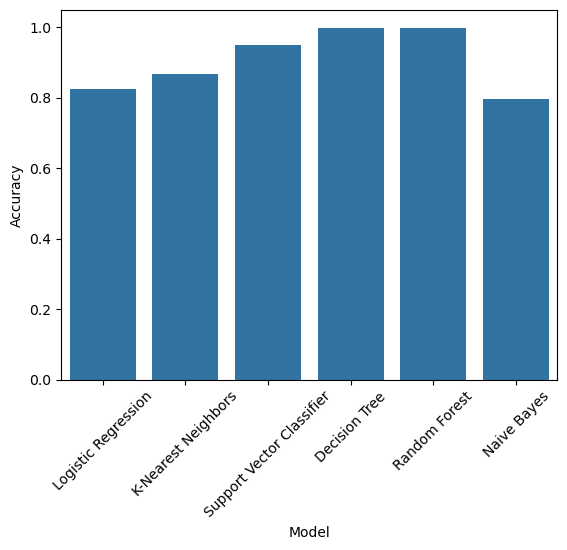

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Classifier', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [log_reg_accuracy, knn_accuracy, svc_accuracy, dtc_accuracy, rfc_accuracy, nb_accuracy]
})

sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.xticks(rotation=45)

print('From the comparison, it appears that the Random Forest Classifier performed the best in terms of accuracy, followed closely by the Decision Tree Classifier. Logistic Regression and K-Nearest Neighbors also showed decent performance, while Naive Bayes had the lowest accuracy among the models tested.')